# S4 - Baseline Models

## Pregled

Implementacija i evaluacija dva baseline ML modela za predikciju srčanih bolesti na oba dataseta.

| # | Model | Tip | Opis |
|---|-------|-----|------|
| 1 | **Logistic Regression** | Linearni | Interpretabilan, probabilistički, brz |
| 2 | **Random Forest** | Ensemble | Robustno, redukuje overfitting |

## Metrike evaluacije

- **Accuracy**, **Balanced Accuracy**
- **Precision**, **Recall**, **F1** (macro, weighted, klasa HD=1)
- **Specificity** (True Negative Rate)
- **ROC-AUC**, **PR-AUC**, **Confusion Matrix**

> **Napomena**: U medicinskom kontekstu poseban naglasak je na **Recall (HD=1)** — smanjiti broj lažno negativnih predikcija (FN) je kritično jer propuštena dijagnoza ima ozbiljne kliničke posljedice.

## Ulaz / Izlaz

- **Ulaz**: `data/processed/preprocessing_output.pkl` (output S3)
- **Izlaz**: `models/baseline_models.pkl`, `models/baseline_results.csv`, figure-i u `figures/`

## Setup - import biblioteka i konfiguracija

In [4]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import os

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    balanced_accuracy_score
)

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 15,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.titlesize': 17,
    'axes.labelsize': 13,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

CLR_NEG = '#4C9BE8'
CLR_POS = '#E8594C'

MODEL_COLORS = {
    'Logistic Regression': '#2196F3',
    'Random Forest': '#FF9800',
}

os.makedirs('models', exist_ok=True)
os.makedirs('figures', exist_ok=True)

print('Setup zavrsen. Seed:', SEED)

Setup zavrsen. Seed: 42


## 0. Učitavanje podataka iz S3 pickle-a

In [5]:
with open('data/processed/preprocessing_output.pkl', 'rb') as f:
    data = pickle.load(f)

# Dataset A - CDC 2022 (SMOTE primijenjen, scaled)
X_a_train = data['X_a_train']
X_a_test = data['X_a_test']
y_a_train = data['y_a_train']
y_a_test = data['y_a_test']
feature_names_a = data['feature_names_a']

# Dataset B - Heart Failure (bez SMOTE, scaled)
X_b_train = data['X_b_train']
X_b_test = data['X_b_test']
y_b_train = data['y_b_train']
y_b_test = data['y_b_test']
feature_names_b = data['feature_names_b']

print('Podaci ucitani iz S3 preprocessing outputa.')
print()
for ds, Xtr, Xte, ytr, yte in [
    ('Dataset A (CDC 2022)', X_a_train, X_a_test, y_a_train, y_a_test),
    ('Dataset B (Heart Failure)', X_b_train, X_b_test, y_b_train, y_b_test),
]:
    ctr = dict(zip(*np.unique(ytr, return_counts=True)))
    cte = dict(zip(*np.unique(yte, return_counts=True)))
    print(f'{ds}:')
    print(f'Train: {Xtr.shape} klase -> {ctr}')
    print(f'Test: {Xte.shape} klase -> {cte}')
    print()

print(f'Feature-i A ({len(feature_names_a)}): {feature_names_a[:5]} ...')
print(f'Feature-i B ({len(feature_names_b)}): {feature_names_b}')

Podaci ucitani iz S3 preprocessing outputa.

Dataset A (CDC 2022):
Train: (671788, 39) klase -> {np.int64(0): np.int64(335894), np.int64(1): np.int64(335894)}
Test: (88995, 39) klase -> {np.int64(0): np.int64(83973), np.int64(1): np.int64(5022)}

Dataset B (Heart Failure):
Train: (734, 11) klase -> {np.int64(0): np.int64(328), np.int64(1): np.int64(406)}
Test: (184, 11) klase -> {np.int64(0): np.int64(82), np.int64(1): np.int64(102)}

Feature-i A (39): ['State', 'Sex', 'GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays'] ...
Feature-i B (11): ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']


## Helper funkcije - evaluacija i treniranje

In [6]:
ARRAY_KEYS = {'y_pred', 'y_prob', 'confusion_matrix',
              'fpr', 'tpr', 'precision_curve', 'recall_curve'}

W = 66   # sirina boxova u ispisu


def _box_line(label, value, label2='', value2='', w=W):
    """Formatira jedan red sa jednim ili dva para label-value."""
    if label2:
        left = f'{label:<26} {value}'
        right = f'{label2:<22} {value2}'
        return f'{left} {right}'
    return f'{label:<26} {value}'


def evaluate_model(model, X_test, y_test, model_name='Model', dataset_name='Dataset'):
    """
    Sveobuhvatna evaluacija klasifikatora na test skupu.
    Vraca dict sa svim metrikama, predikcijama i podacima za krivulje.
    """
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    prec_w = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec_w = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_w = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    prec_m = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec_m = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1_m = f1_score(y_test, y_pred, average='macro', zero_division=0)

    prec_1 = precision_score(y_test, y_pred, pos_label=1, average='binary', zero_division=0)
    rec_1 = recall_score(y_test, y_pred, pos_label=1, average='binary', zero_division=0)
    f1_1 = f1_score(y_test, y_pred, pos_label=1, average='binary', zero_division=0)

    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    fpr, tpr, _  = roc_curve(y_test, y_prob)
    prec_c, rec_c, _ = precision_recall_curve(y_test, y_prob)

    metrics = {
        'Model': model_name,
        'Dataset': dataset_name,
        'Accuracy': round(acc, 4),
        'Balanced Accuracy': round(bal_acc, 4),
        'Precision (weighted)': round(prec_w, 4),
        'Recall (weighted)': round(rec_w, 4),
        'F1 (weighted)': round(f1_w, 4),
        'Precision (macro)': round(prec_m, 4),
        'Recall (macro)': round(rec_m, 4),
        'F1 (macro)': round(f1_m, 4),
        'Precision (HD)': round(prec_1, 4),
        'Recall (HD)': round(rec_1, 4),
        'F1 (HD)': round(f1_1, 4),
        'Specificity': round(specificity, 4),
        'ROC-AUC': round(roc_auc, 4),
        'PR-AUC': round(pr_auc, 4),
        'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn),
        'y_pred': y_pred,
        'y_prob': y_prob,
        'confusion_matrix': cm,
        'fpr': fpr, 'tpr': tpr,
        'precision_curve': prec_c,
        'recall_curve': rec_c,
    }

    # Ispis
    SEP = '=' * W
    sep = '-' * W
    title = f' {model_name} | {dataset_name}'
    print()
    print(SEP)
    print(title)
    print(SEP)
    print(f'{"Accuracy":<26} {acc:.4f} {"Balanced Accuracy":<22} {bal_acc:.4f}')
    print(f'{"Precision (macro)":<26} {prec_m:.4f} {"Recall (macro)":<22} {rec_m:.4f}')
    print(f'{"F1-score (macro)":<26} {f1_m:.4f}')
    print(sep)
    print(f'Heart Disease class  (HD = 1)')
    print(sep)
    print(f'{"Precision":<26} {prec_1:.4f} {"Recall (Sensitivity)":<22} {rec_1:.4f}')
    print(f'{"F1-score":<26} {f1_1:.4f} {"Specificity (TNR)":<22} {specificity:.4f}')
    print(sep)
    print(f'{"ROC-AUC":<26} {roc_auc:.4f} {"PR-AUC":<22} {pr_auc:.4f}')
    print(sep)
    print(f'Confusion Matrix')
    print(f'{"":>20} {"Pred: No HD":>14} {"Pred: HD":>10}')
    print(f'{"Actual: No HD":>20} {tn:>14,} {fp:>10,}')
    print(f'{"Actual: HD":>20} {fn:>14,} {tp:>10,}')
    print(SEP)

    return metrics


def train_and_evaluate(clf, X_train, y_train, X_test, y_test, model_name, dataset_name):
    """Trenira model (s mjerenjem vremena) i evaluira na test skupu."""
    print(f'Treniranje: {model_name} | {dataset_name} ({X_train.shape[0]:,} uzoraka)...')
    t0 = time.time()
    clf.fit(X_train, y_train)
    elapsed = time.time() - t0
    print(f'Gotovo. Trajanje: {elapsed:.1f}s')

    metrics = evaluate_model(clf, X_test, y_test, model_name, dataset_name)
    metrics['train_time'] = round(elapsed, 2)
    return clf, metrics


# Storage
all_results = []  # summary dicts (bez array-a) -> za DataFrame
all_results_vis = {}  # puni dicts (s array-ima) -> za vizualizacije
models_a = {}  # trenirani modeli Dataset A
models_b = {}  # trenirani modeli Dataset B

print('Helper funkcije definisane.')

Helper funkcije definisane.


## 1. Logistic Regression

Logistička regresija je linearni model koji direktno modelira vjerovatnoću $P(y=1|\mathbf{x})$ putem sigmoid funkcije. Odabrana je kao primarni baseline jer pruža kalibrirana probabilistička objašnjenja, koeficijenti su direktno interpretabilni kao log-odds, te je robustna na visokodimenzionalne prostore featura.

**Parametri**: `solver='saga'` — optimalan za velike datasete (O(n) po iteraciji). `C=1.0` - inverz regularizacijskog parametra.

In [7]:
MODEL_NAME = 'Logistic Regression'

lr_a, metrics_lr_a = train_and_evaluate(
    LogisticRegression(C=1.0, solver='saga', max_iter=1000, random_state=SEED, n_jobs=-1),
    X_a_train, y_a_train, X_a_test, y_a_test,
    MODEL_NAME, 'Dataset A'
)

lr_b, metrics_lr_b = train_and_evaluate(
    LogisticRegression(C=1.0, solver='saga', max_iter=1000, random_state=SEED, n_jobs=-1),
    X_b_train, y_b_train, X_b_test, y_b_test,
    MODEL_NAME, 'Dataset B'
)

all_results_vis[f'{MODEL_NAME}_A'] = metrics_lr_a
all_results_vis[f'{MODEL_NAME}_B'] = metrics_lr_b
models_a[MODEL_NAME] = lr_a
models_b[MODEL_NAME] = lr_b

for m in [metrics_lr_a, metrics_lr_b]:
    all_results.append({k: v for k, v in m.items() if k not in ARRAY_KEYS})

Treniranje: Logistic Regression | Dataset A (671,788 uzoraka)...
Gotovo. Trajanje: 15.5s

 Logistic Regression | Dataset A
Accuracy                   0.8222 Balanced Accuracy      0.7952
Precision (macro)          0.5955 Recall (macro)         0.7952
F1-score (macro)           0.6122
------------------------------------------------------------------
Heart Disease class  (HD = 1)
------------------------------------------------------------------
Precision                  0.2078 Recall (Sensitivity)   0.7648
F1-score                   0.3268 Specificity (TNR)      0.8256
------------------------------------------------------------------
ROC-AUC                    0.8780 PR-AUC                 0.3913
------------------------------------------------------------------
Confusion Matrix
                        Pred: No HD   Pred: HD
       Actual: No HD         69,327     14,646
          Actual: HD          1,181      3,841
Treniranje: Logistic Regression | Dataset B (734 uzoraka)...
Gotovo

## 2. Random Forest

**Random Forest** pravi više stabala odlučivanja koristeći različite nasumično odabrane dijelove podataka i karakteristika (*featurea*). Na kraju kombinuje rezultate svih stabala kako bi dao tačniju i stabilniju predikciju od jednog pojedinačnog stabla.

**Parametri:**

* `n_estimators=100` - koristi 100 stabala kao početnu postavku.
* `max_features='sqrt'` - za svako stablo koristi nasumično odabrani broj karakteristika, što je često dobar izbor za klasifikaciju.
* `n_jobs=-1` - koristi sve dostupne procesorske jezgre kako bi model radio brže.


> **Napomena**: Treniranje na Dataset A (671k uzoraka) može potrajati 2–5 minuta.

In [8]:
MODEL_NAME = 'Random Forest'

rf_a, metrics_rf_a = train_and_evaluate(
    RandomForestClassifier(
        n_estimators=100, max_features='sqrt', max_depth=20,
        min_samples_split=10, min_samples_leaf=5,
        random_state=SEED, n_jobs=-1
    ),
    X_a_train, y_a_train, X_a_test, y_a_test,
    MODEL_NAME, 'Dataset A'
)

rf_b, metrics_rf_b = train_and_evaluate(
    RandomForestClassifier(
        n_estimators=100, max_features='sqrt', max_depth=None,
        min_samples_split=5, min_samples_leaf=2,
        random_state=SEED, n_jobs=-1
    ),
    X_b_train, y_b_train, X_b_test, y_b_test,
    MODEL_NAME, 'Dataset B'
)

all_results_vis[f'{MODEL_NAME}_A'] = metrics_rf_a
all_results_vis[f'{MODEL_NAME}_B'] = metrics_rf_b
models_a[MODEL_NAME] = rf_a
models_b[MODEL_NAME] = rf_b

for m in [metrics_rf_a, metrics_rf_b]:
    all_results.append({k: v for k, v in m.items() if k not in ARRAY_KEYS})

print(f'Svi baseline modeli trenirani. Ukupno: {len(all_results)} (2 modela x 2 dataseta)')

Treniranje: Random Forest | Dataset A (671,788 uzoraka)...
Gotovo. Trajanje: 74.0s

 Random Forest | Dataset A
Accuracy                   0.9400 Balanced Accuracy      0.7038
Precision (macro)          0.7165 Recall (macro)         0.7038
F1-score (macro)           0.7099
------------------------------------------------------------------
Heart Disease class  (HD = 1)
------------------------------------------------------------------
Precision                  0.4666 Recall (Sensitivity)   0.4375
F1-score                   0.4515 Specificity (TNR)      0.9701
------------------------------------------------------------------
ROC-AUC                    0.8791 PR-AUC                 0.3798
------------------------------------------------------------------
Confusion Matrix
                        Pred: No HD   Pred: HD
       Actual: No HD         81,461      2,512
          Actual: HD          2,825      2,197
Treniranje: Random Forest | Dataset B (734 uzoraka)...
Gotovo. Trajanje: 0.2s



## 3. Rezultati - usporedna tabela

In [9]:
# Usporedna tabela 

results_df = pd.DataFrame(all_results)

TABLE_COLS = [
    'Model',
    'Accuracy', 'Balanced Accuracy',
    'Precision (HD)', 'Recall (HD)', 'F1 (HD)',
    'Specificity',
    'F1 (macro)',
    'ROC-AUC', 'PR-AUC',
]

W2 = 100

for ds_label, ds_key in [('Dataset A - CDC 2022 (N = 444,975)', 'Dataset A'),
                          ('Dataset B - Heart Failure (N = 918)', 'Dataset B')]:

    sub = (
        results_df[results_df['Dataset'] == ds_key][TABLE_COLS]
        .sort_values('ROC-AUC', ascending=False)
        .reset_index(drop=True)
    )

    # header
    print()
    print('=' * W2)
    print(f'{ds_label}')
    print('=' * W2)

    # column header row
    h = (f'{"Model":<22} {"Accuracy":>9} {"Bal.Acc":>8}  '
         f'{"Prec(HD)":>9} {"Rec(HD)":>8} {"F1(HD)":>7}  '
         f'{"Spec":>7} {"F1mac":>7} {"ROC-AUC":>8} {"PR-AUC":>7}')
    print(h)
    print('-' * W2)

    # data rows
    for _, row in sub.iterrows():
        print(
            f'{row["Model"]:<22}  '
            f'{row["Accuracy"]:>9.4f}  '
            f'{row["Balanced Accuracy"]:>8.4f}  '
            f'{row["Precision (HD)"]:>9.4f}  '
            f'{row["Recall (HD)"]:>8.4f}  '
            f'{row["F1 (HD)"]:>7.4f}  '
            f'{row["Specificity"]:>7.4f}  '
            f'{row["F1 (macro)"]:>7.4f}  '
            f'{row["ROC-AUC"]:>8.4f}  '
            f'{row["PR-AUC"]:>7.4f}'
        )

    print('=' * W2)

results_df.to_csv('models/baseline_results.csv', index=False)
print()
print('Sacuvano: models/baseline_results.csv')


Dataset A - CDC 2022 (N = 444,975)
Model                   Accuracy  Bal.Acc   Prec(HD)  Rec(HD)  F1(HD)     Spec   F1mac  ROC-AUC  PR-AUC
----------------------------------------------------------------------------------------------------
Random Forest              0.9400    0.7038     0.4666    0.4375   0.4515   0.9701   0.7099    0.8791   0.3798
Logistic Regression        0.8222    0.7952     0.2078    0.7648   0.3268   0.8256   0.6122    0.8780   0.3913

Dataset B - Heart Failure (N = 918)
Model                   Accuracy  Bal.Acc   Prec(HD)  Rec(HD)  F1(HD)     Spec   F1mac  ROC-AUC  PR-AUC
----------------------------------------------------------------------------------------------------
Random Forest              0.9022    0.8998     0.9038    0.9216   0.9126   0.8780   0.9008    0.9267   0.9141
Logistic Regression        0.8696    0.8620     0.8482    0.9314   0.8879   0.7927   0.8660    0.8969   0.8793

Sacuvano: models/baseline_results.csv


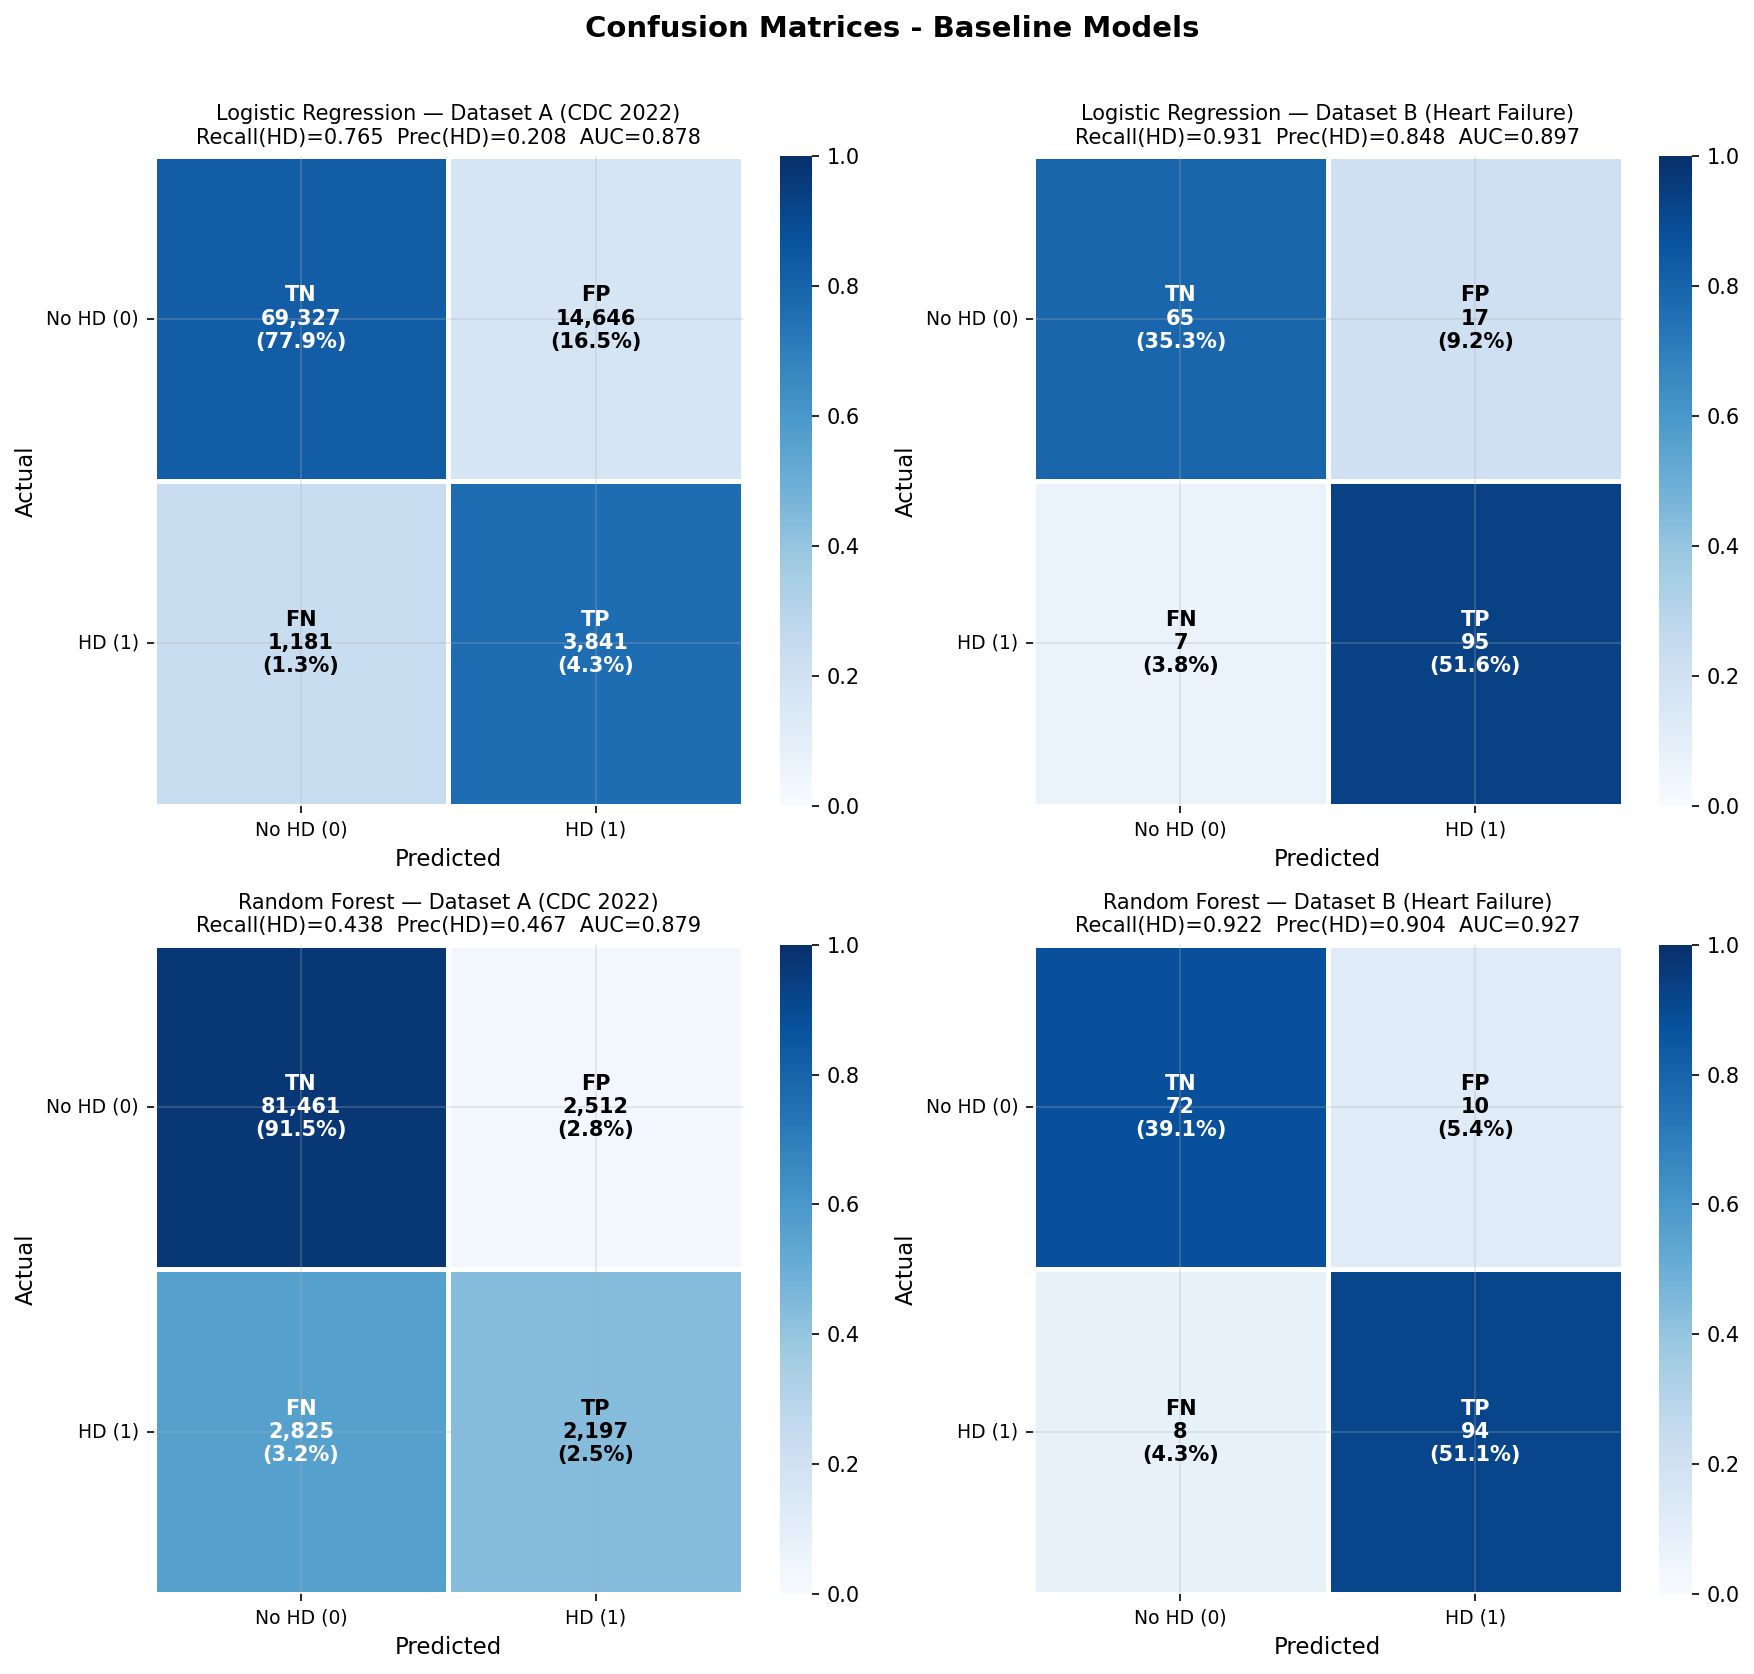

Sacuvano: figures/S4_confusion_matrices.png


In [10]:
# Confusion Matrices 

model_names_list = list(MODEL_COLORS.keys())
ds_pairs = [('A', 'Dataset A (CDC 2022)'), ('B', 'Dataset B (Heart Failure)')]

fig, axes = plt.subplots(2, 2, figsize=(12, 11))

for row, mname in enumerate(model_names_list):
    for col, (ds_key, ds_label) in enumerate(ds_pairs):
        key = f'{mname}_{ds_key}'
        m = all_results_vis[key]
        cm = m['confusion_matrix']
        tn, fp, fn, tp = cm.ravel()
        ax = axes[row, col]

        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        sns.heatmap(
            cm_norm, annot=False, cmap='Blues',
            ax=ax, cbar=True, linewidths=1.5, linecolor='white',
            vmin=0, vmax=1
        )

        cell_labels = [
            [f'TN\n{tn:,}\n({tn / cm.sum() * 100:.1f}%)',
             f'FP\n{fp:,}\n({fp / cm.sum() * 100:.1f}%)'],
            [f'FN\n{fn:,}\n({fn / cm.sum() * 100:.1f}%)',
             f'TP\n{tp:,}\n({tp / cm.sum() * 100:.1f}%)']
        ]
        for i in range(2):
            for j in range(2):
                color = 'white' if cm_norm[i, j] > 0.55 else 'black'
                ax.text(j + 0.5, i + 0.5, cell_labels[i][j],
                        ha='center', va='center', fontsize=12,
                        color=color, fontweight='bold')

        rec = m['Recall (HD)']
        prec = m['Precision (HD)']
        auc = m['ROC-AUC']
        ax.set_title(
            f'{mname} — {ds_label}\n'
            f'Recall(HD)={rec:.3f}  Prec(HD)={prec:.3f}  AUC={auc:.3f}',
            fontsize=12
        )
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        ax.set_xticklabels(['No HD (0)', 'HD (1)'], fontsize=11)
        ax.set_yticklabels(['No HD (0)', 'HD (1)'], fontsize=11, rotation=0)

plt.suptitle('Confusion Matrices - Baseline Models', fontsize=16,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/S4_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sacuvano: figures/S4_confusion_matrices.png')

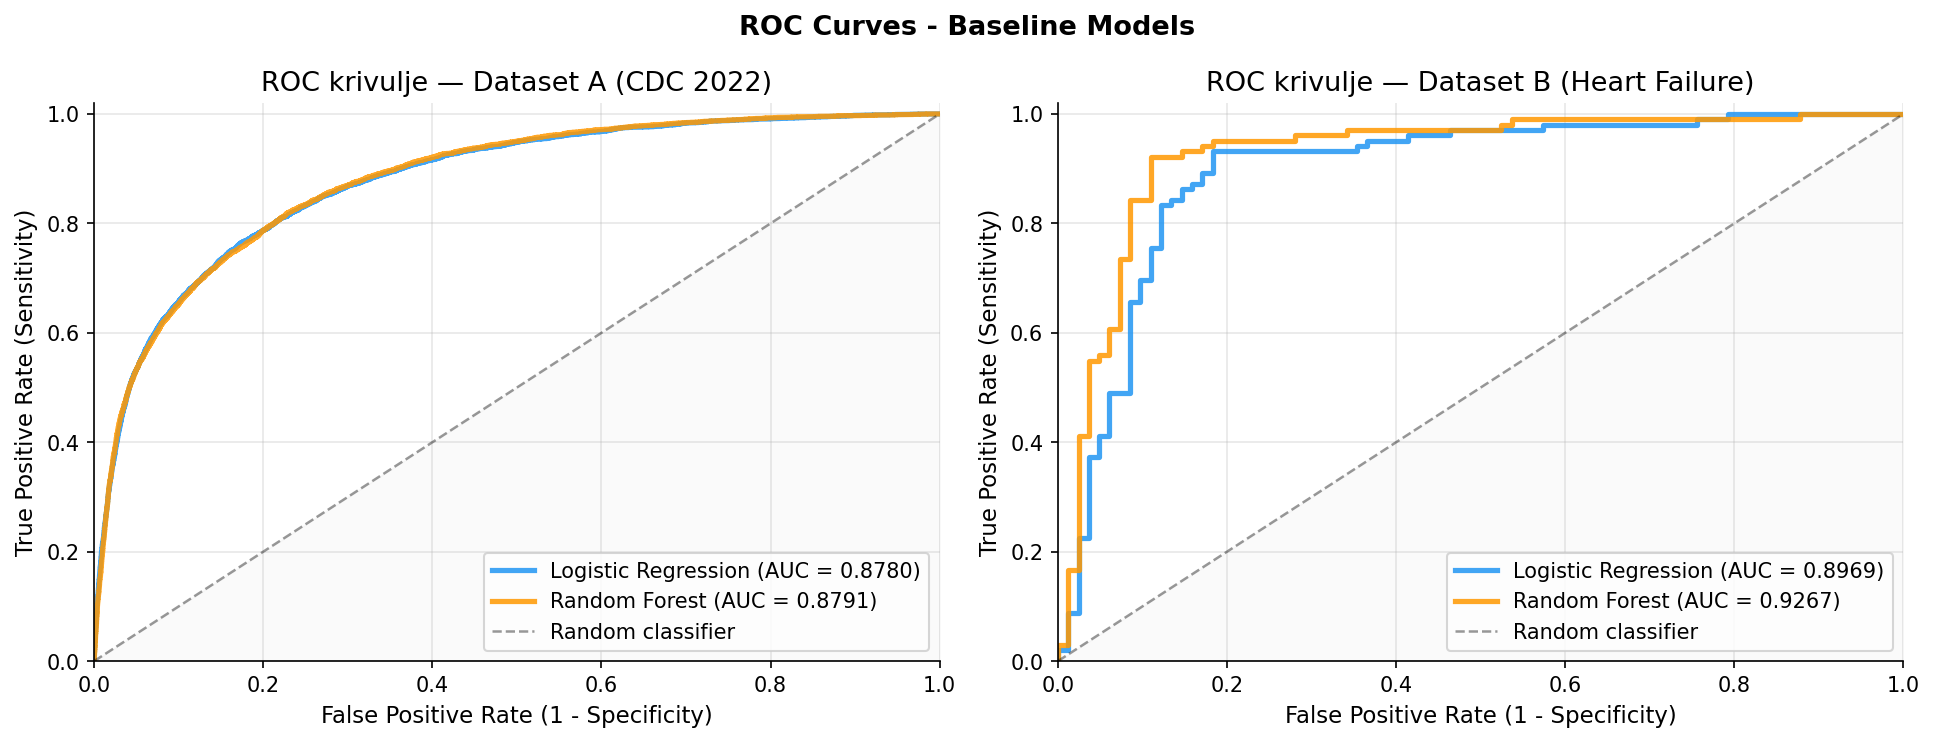

Sacuvano: figures/S4_roc_curves.png


In [11]:
# ROC Curves 

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (ds_key, ds_title) in zip(axes, [
    ('A', 'Dataset A (CDC 2022)'),
    ('B', 'Dataset B (Heart Failure)')
]):
    for mname, color in MODEL_COLORS.items():
        m = all_results_vis[f'{mname}_{ds_key}']
        ax.plot(m['fpr'], m['tpr'],
                label=f'{mname} (AUC = {m["ROC-AUC"]:.4f})',
                color=color, lw=2.5, alpha=0.85)

    ax.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.4, label='Random classifier')
    ax.fill_between([0, 1], [0, 1], alpha=0.04, color='grey')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.02])
    ax.set_xlabel('False Positive Rate (1 - Specificity)')
    ax.set_ylabel('True Positive Rate (Sensitivity)')
    ax.set_title(f'ROC Curves — {ds_title}')
    ax.legend(loc='lower right', fontsize=12)

plt.suptitle('ROC Curves - Baseline Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/S4_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sacuvano: figures/S4_roc_curves.png')

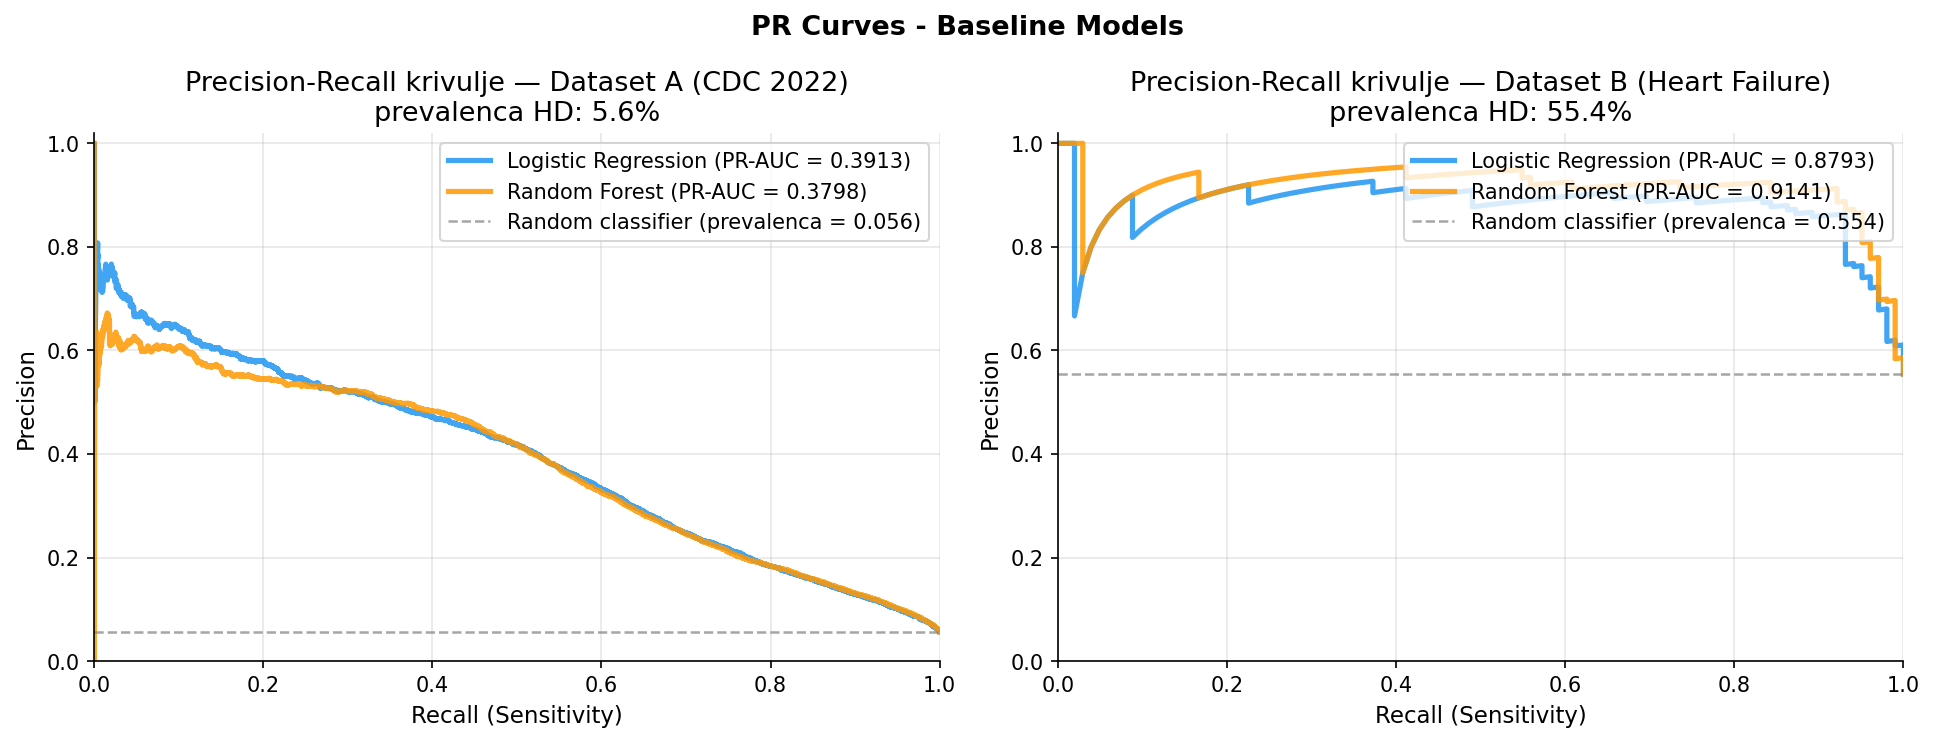

Sacuvano: figures/S4_pr_curves.png


In [12]:
# Precision-Recall Curves 

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (ds_key, ds_title, y_test_ref) in zip(axes, [
    ('A', 'Dataset A (CDC 2022)',      y_a_test),
    ('B', 'Dataset B (Heart Failure)', y_b_test)
]):
    prevalence = y_test_ref.sum() / len(y_test_ref)

    for mname, color in MODEL_COLORS.items():
        m = all_results_vis[f'{mname}_{ds_key}']
        ax.plot(m['recall_curve'], m['precision_curve'],
                label=f'{mname} (PR-AUC = {m["PR-AUC"]:.4f})',
                color=color, lw=2.5, alpha=0.85)

    ax.axhline(y=prevalence, color='grey', linestyle='--', lw=1.2, alpha=0.7,
               label=f'Random classifier (prevalenca = {prevalence:.3f})')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.02])
    ax.set_xlabel('Recall (Sensitivity)')
    ax.set_ylabel('Precision')
    ax.set_title(f'Precision-Recall Curves — {ds_title}\nHD prevalence: {prevalence:.1%}')
    ax.legend(loc='upper right', fontsize=12)

plt.suptitle('PR Curves - Baseline Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/S4_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sacuvano: figures/S4_pr_curves.png')

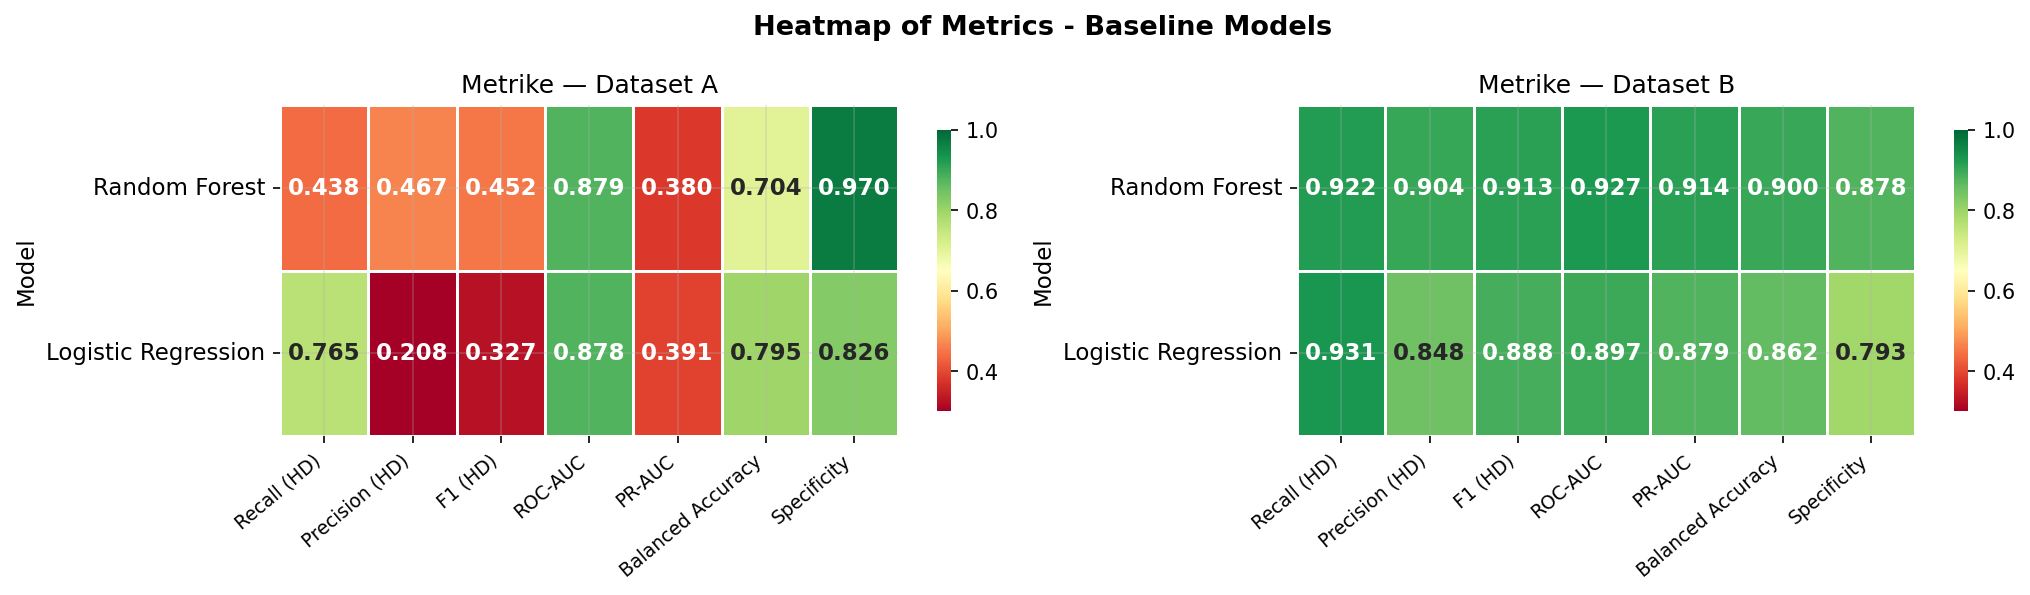

Sacuvano: figures/S4_metrics_heatmap.png


In [13]:
# Metrics Heatmap 

metric_cols = [
    'Recall (HD)', 'Precision (HD)', 'F1 (HD)',
    'ROC-AUC', 'PR-AUC',
    'Balanced Accuracy', 'Specificity'
]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, ds in zip(axes, ['Dataset A', 'Dataset B']):
    sub = (
        results_df[results_df['Dataset'] == ds]
        .sort_values('ROC-AUC', ascending=False)
        .set_index('Model')[metric_cols]
    )
    sns.heatmap(
        sub, annot=True, fmt='.3f', cmap='RdYlGn',
        ax=ax, vmin=0.3, vmax=1.0,
        linewidths=0.5, cbar_kws={'shrink': 0.85},
        annot_kws={'size': 13, 'weight': 'bold'}
    )
    ax.set_title(f'Metrike — {ds}', fontsize=14)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=11)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=13)

plt.suptitle('Heatmap of Metrics - Baseline Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/S4_metrics_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sacuvano: figures/S4_metrics_heatmap.png')

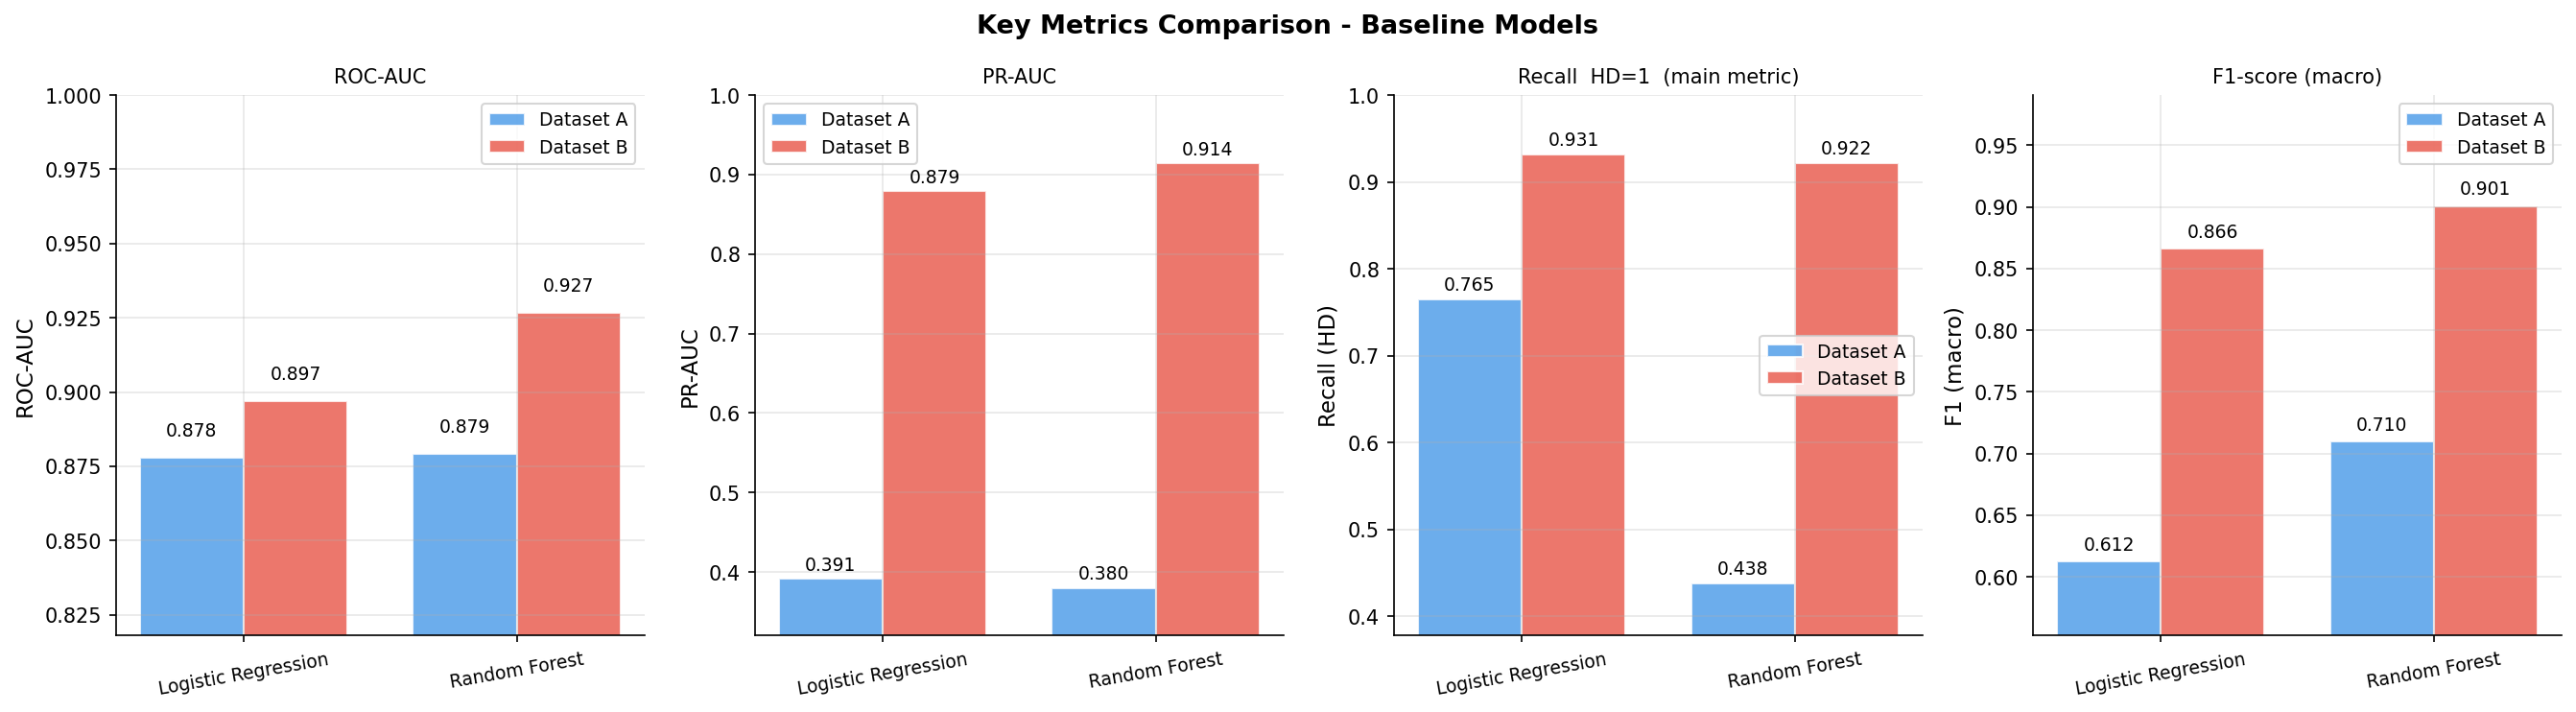

Sacuvano: figures/S4_metrics_comparison.png


In [15]:
# Bar Chart: usporedba kljucnih metrika 

key_metrics = [
    ('ROC-AUC', 'ROC-AUC'),
    ('PR-AUC', 'PR-AUC'),
    ('Recall (HD)', 'Recall  HD=1  (main metric)'),
    ('F1 (macro)', 'F1-score (macro)'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

ds_a_sub = results_df[results_df['Dataset'] == 'Dataset A']
ds_b_sub = results_df[results_df['Dataset'] == 'Dataset B']

x = np.arange(len(model_names_list))
width = 0.38

for ax, (col, title) in zip(axes, key_metrics):
    vals_a = [float(ds_a_sub[ds_a_sub['Model'] == m][col].values[0]) for m in model_names_list]
    vals_b = [float(ds_b_sub[ds_b_sub['Model'] == m][col].values[0]) for m in model_names_list]

    bars_a = ax.bar(x - width / 2, vals_a, width,
                    label='Dataset A', color=CLR_NEG, alpha=0.82, edgecolor='white')
    bars_b = ax.bar(x + width / 2, vals_b, width,
                    label='Dataset B', color=CLR_POS, alpha=0.82, edgecolor='white')

    for bar in list(bars_a) + list(bars_b):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., h + 0.006,
                f'{h:.3f}', ha='center', va='bottom', fontsize=11)

    ax.set_xticks(x)
    ax.set_xticklabels(model_names_list, fontsize=11, rotation=10)
    ax.set_ylabel(col)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=11)
    lo = max(0.0, min(vals_a + vals_b) - 0.06)
    hi = min(1.0, max(vals_a + vals_b) + 0.09)
    ax.set_ylim(lo, hi)

plt.suptitle('Key Metrics Comparison - Baseline Models',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/S4_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sacuvano: figures/S4_metrics_comparison.png')

## 4. Čuvanje modela

In [16]:
baseline_output = {
    'models_a': models_a,
    'models_b': models_b,
    'results_df': results_df,
    'all_results_vis': all_results_vis,
    'model_names': list(models_a.keys()),
    'feature_names_a': feature_names_a,
    'feature_names_b': feature_names_b,
}

with open('models/baseline_models.pkl', 'wb') as f:
    pickle.dump(baseline_output, f)

print('Sacuvano: models/baseline_models.pkl')
print()
print(f'models_a: {list(models_a.keys())}')
print(f'models_b: {list(models_b.keys())}')
print(f'results: {results_df.shape}')
print()
print('S4 -- Baseline Models: ZAVRSEN!')

Sacuvano: models/baseline_models.pkl

models_a: ['Logistic Regression', 'Random Forest']
models_b: ['Logistic Regression', 'Random Forest']
results: (4, 21)

S4 -- Baseline Models: ZAVRSEN!


## Zaključak — S4

U ovom notebooku implementirana su i testirana dva osnovna modela (Logistic Regression i Random Forest) na oba dataseta koristeći više metrika za procjenu performansi.

### Napomene za tumačenje rezultata

- **Testni skup** zadržava stvarnu (neuravnoteženu) raspodjelu klasa kako bi rezultati bili realniji  
- **Recall (HD=1)** je važna metrika - veći Recall znači manje propuštenih slučajeva bolesti (**FN**)  
- **Balanced Accuracy** prikazuje performanse modela bez velikog utjecaja neuravnoteženih podataka  
- **PR-AUC** može biti korisniji od **ROC-AUC** kod neuravnoteženih skupova podataka (kao što je Dataset A)